In [120]:
#https://platform.olimpiada-ai.ro/ro/problems/190
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import HDBSCAN
import numpy as np

df = pd.read_csv('data.csv')

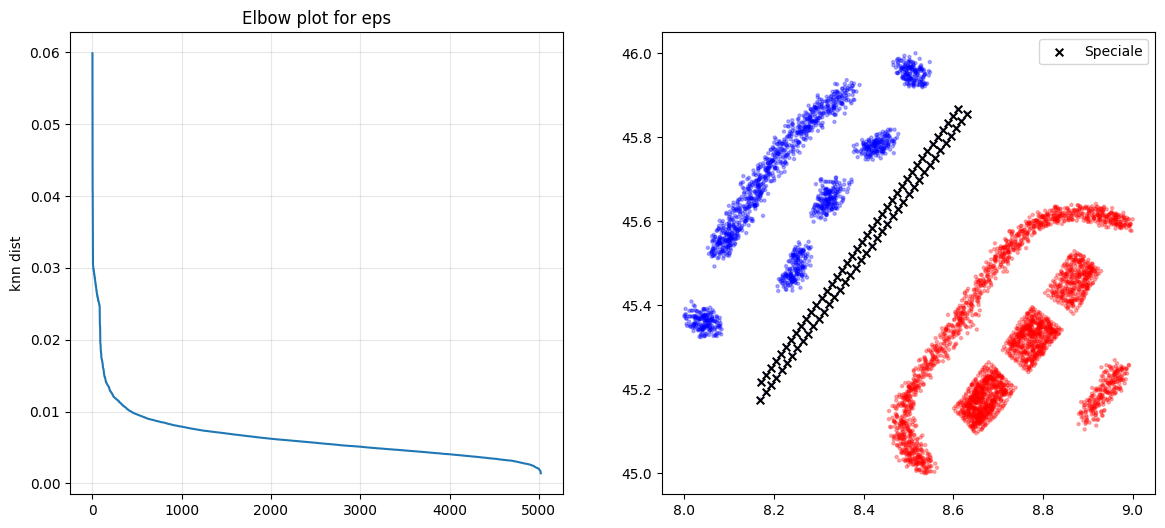

In [112]:
# TASK 1
X = df.drop(columns=['Team', 'ID'])

# Elbow Method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

k = 5  # same value as min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)

k_distances = np.sort(distances[:, k-1])[::-1]
ax1.plot(k_distances)
ax1.set_ylabel('knn dist')
ax1.set_title('Elbow plot for eps')
ax1.grid(True, alpha=.3)

# DBSCAN
db = DBSCAN(eps=0.024, min_samples=5).fit(X)
noise = db.labels_ == -1
special = noise & (df['Team'] == 0)

# Plot findings
ax2.scatter(df['x'], df['y'], c=df['Team'], cmap='bwr', s=5, alpha=0.3)
ax2.scatter(df.loc[special, 'x'], df.loc[special, 'y'],
            c='black', s=30, marker='x', label='Speciale')
plt.legend()
plt.show()

task1ans = special.astype(int)

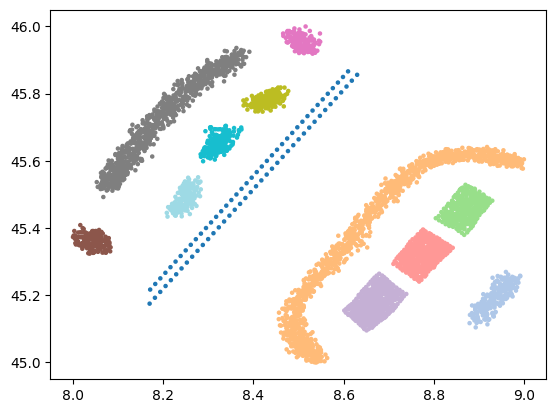

In [118]:
# Task 2
# HDB because it doesn t relly on distance
hdb = HDBSCAN(min_cluster_size=30).fit(X)
task2ans = hdb.labels_
plt.scatter(df['x'], df['y'], c=task2ans, cmap='tab20', s=5)
plt.show()

In [119]:
# Dataframe
rows = []
for id,pred in zip(df['ID'], task1ans):
    rows.append({
        'subtaskID': 1,
        'datapointID': id,
        'answer': pred
    })
for id,pred in zip(df['ID'], task2ans):
    rows.append({
        'subtaskID': 2,
        'datapointID': id,
        'answer': pred
    })
subDf = pd.DataFrame(rows)
subDf.to_csv('submission.csv', index=False)